In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('/Users/Іра/PycharmProjects/pythonProject11/pythonProject11/Portfolio Projects/Churn Prediction/E-commerce_Customer_Segmentation_2026.csv')
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  str    
 1   customer_segment               50000 non-null  str    
 2   segment_category               50000 non-null  str    
 3   age                            50000 non-null  int64  
 4   age_group                      50000 non-null  str    
 5   gender                         50000 non-null  str    
 6   country                        50000 non-null  str    
 7   city                           50000 non-null  str    
 8   income_bracket                 50000 non-null  str    
 9   education_level                50000 non-null  str    
 10  employment_type                50000 non-null  str    
 11  marital_status                 50000 non-null  str    
 12  tenure_months                  50000 non-null  int64  
 1

In [4]:
df.isnull().sum()

customer_id                          0
customer_segment                     0
segment_category                     0
age                                  0
age_group                            0
gender                               0
country                              0
city                                 0
income_bracket                       0
education_level                      0
employment_type                      0
marital_status                       0
tenure_months                        0
total_purchases                      0
avg_order_value_usd                  0
total_spent_usd                      0
purchase_frequency                   0
days_since_last_purchase             0
preferred_category_1                 0
preferred_category_2             16743
preferred_category_3             33257
shopping_channel                     0
device_used                          0
payment_method                       0
return_count                         0
complaint_count          

In [5]:
df[df.duplicated()]

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category


In [6]:
category_cols = [
    c for c in df.select_dtypes(include=['object', 'str']).columns 
    if c != 'customer_id'
]

summary_df = pd.DataFrame({
    'Column Name': category_cols,
    'Unique Count': [df[col].nunique() for col in category_cols],
    'Categories': [list(df[col].dropna().unique()) for col in category_cols]
})

print(summary_df)

                Column Name  Unique Count  \
0          customer_segment             4   
1          segment_category             6   
2                 age_group             6   
3                    gender             2   
4                   country            17   
5                      city           157   
6            income_bracket             6   
7           education_level             5   
8           employment_type             5   
9            marital_status             4   
10       purchase_frequency             5   
11     preferred_category_1            12   
12     preferred_category_2            12   
13     preferred_category_3            12   
14         shopping_channel             4   
15              device_used             4   
16           payment_method             5   
17       satisfaction_level             5   
18             loyalty_tier             5   
19    social_media_presence           156   
20  customer_value_category             5   
21        

# Visualisations

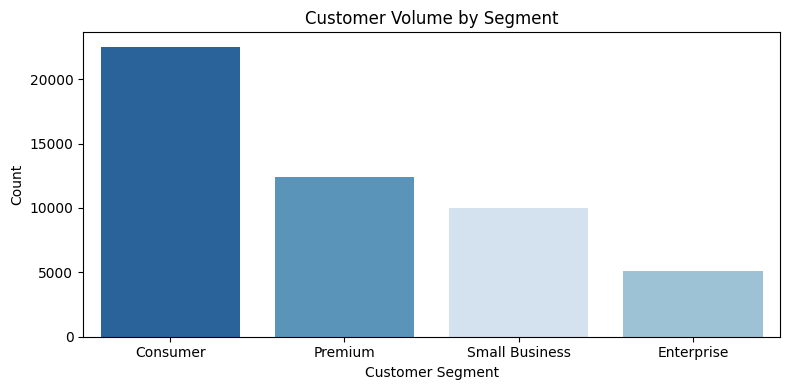

In [7]:
plt.figure(figsize = (8, 4))

sns.countplot(
    data = df, 
    x = 'customer_segment', 
    hue = 'customer_segment', 
    palette = 'Blues_r', 
    order = df['customer_segment'].value_counts().index,
    legend = False
)

plt.title('Customer Volume by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

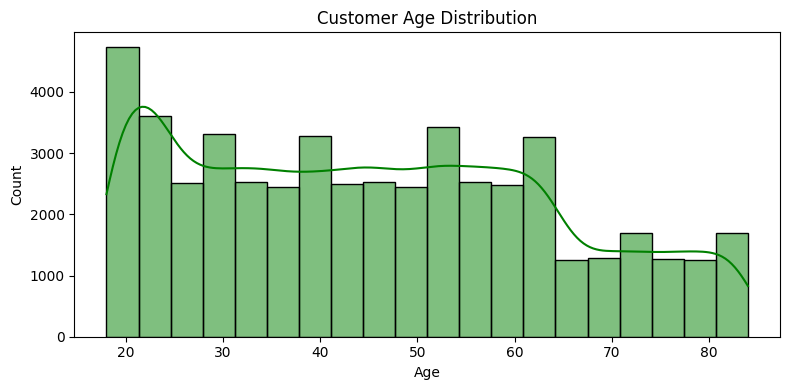

In [8]:
plt.figure(figsize = (8, 4))
sns.histplot(df['age'], kde = True, bins = 20, color = 'green')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

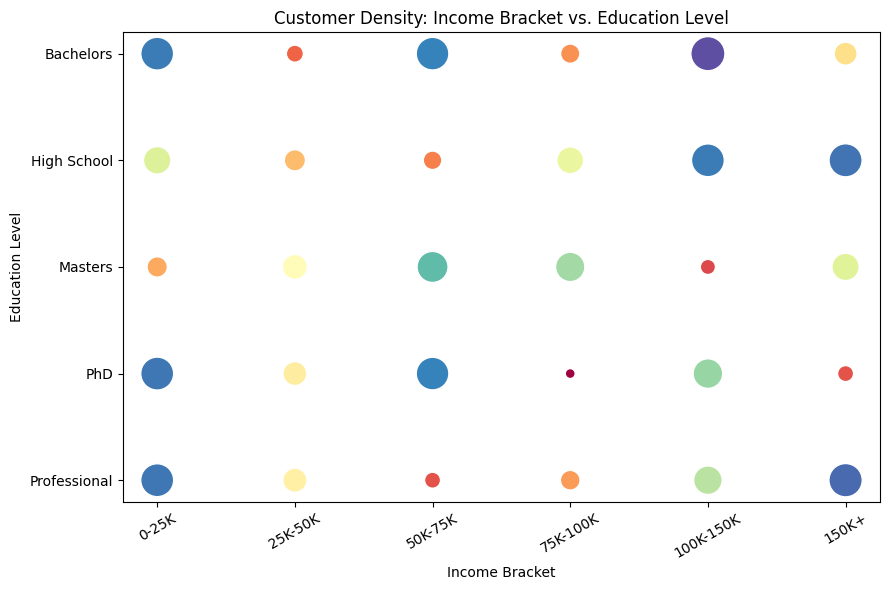

In [9]:
income_order = ['0-25K', '25K-50K', '50K-75K', '75K-100K', '100K-150K', '150K+']

df['income_bracket'] = pd.Categorical(
    df['income_bracket'], 
    categories = income_order, 
    ordered = True
)

cat_counts = df.groupby(['income_bracket', 'education_level'], observed=False).size().reset_index(name='customer_count')

plt.figure(figsize = (9, 6))
sns.scatterplot(
    data = cat_counts, 
    x = 'income_bracket', 
    y = 'education_level', 
    size = 'customer_count', 
    hue ='customer_count', 
    sizes = (50, 600), 
    palette = 'Spectral', 
    legend = False
)

plt.title('Customer Density: Income Bracket vs. Education Level')
plt.xlabel('Income Bracket')
plt.ylabel('Education Level')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

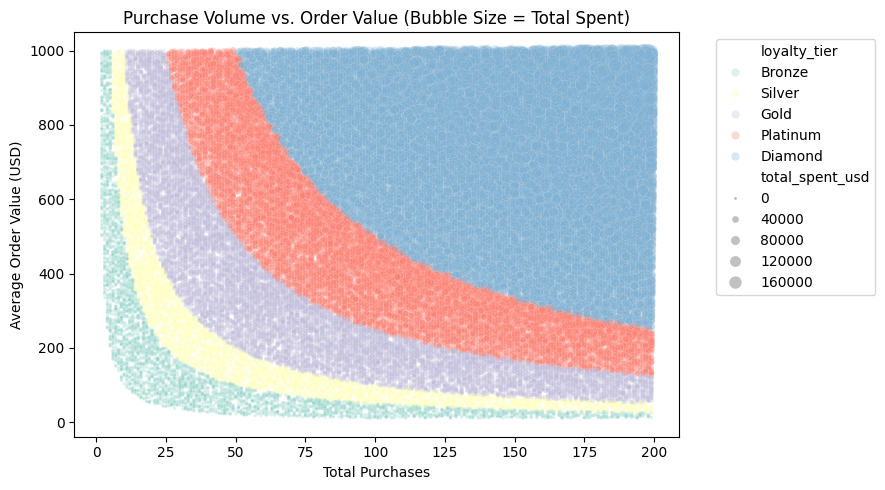

In [10]:
loyalty_order = ['Bronze', 'Silver', 'Gold', 'Platinum', 'Diamond']
plt.figure(figsize = (9, 5))

sns.scatterplot(
    data = df, 
    x = 'total_purchases', 
    y = 'avg_order_value_usd', 
    size = 'total_spent_usd', 
    hue = 'loyalty_tier',
    hue_order = loyalty_order,
    palette = 'Set3',
    sizes = (5, 100), 
    alpha = 0.3
)

plt.title('Purchase Volume vs. Order Value (Bubble Size = Total Spent)')
plt.xlabel('Total Purchases')
plt.ylabel('Average Order Value (USD)')
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show() 

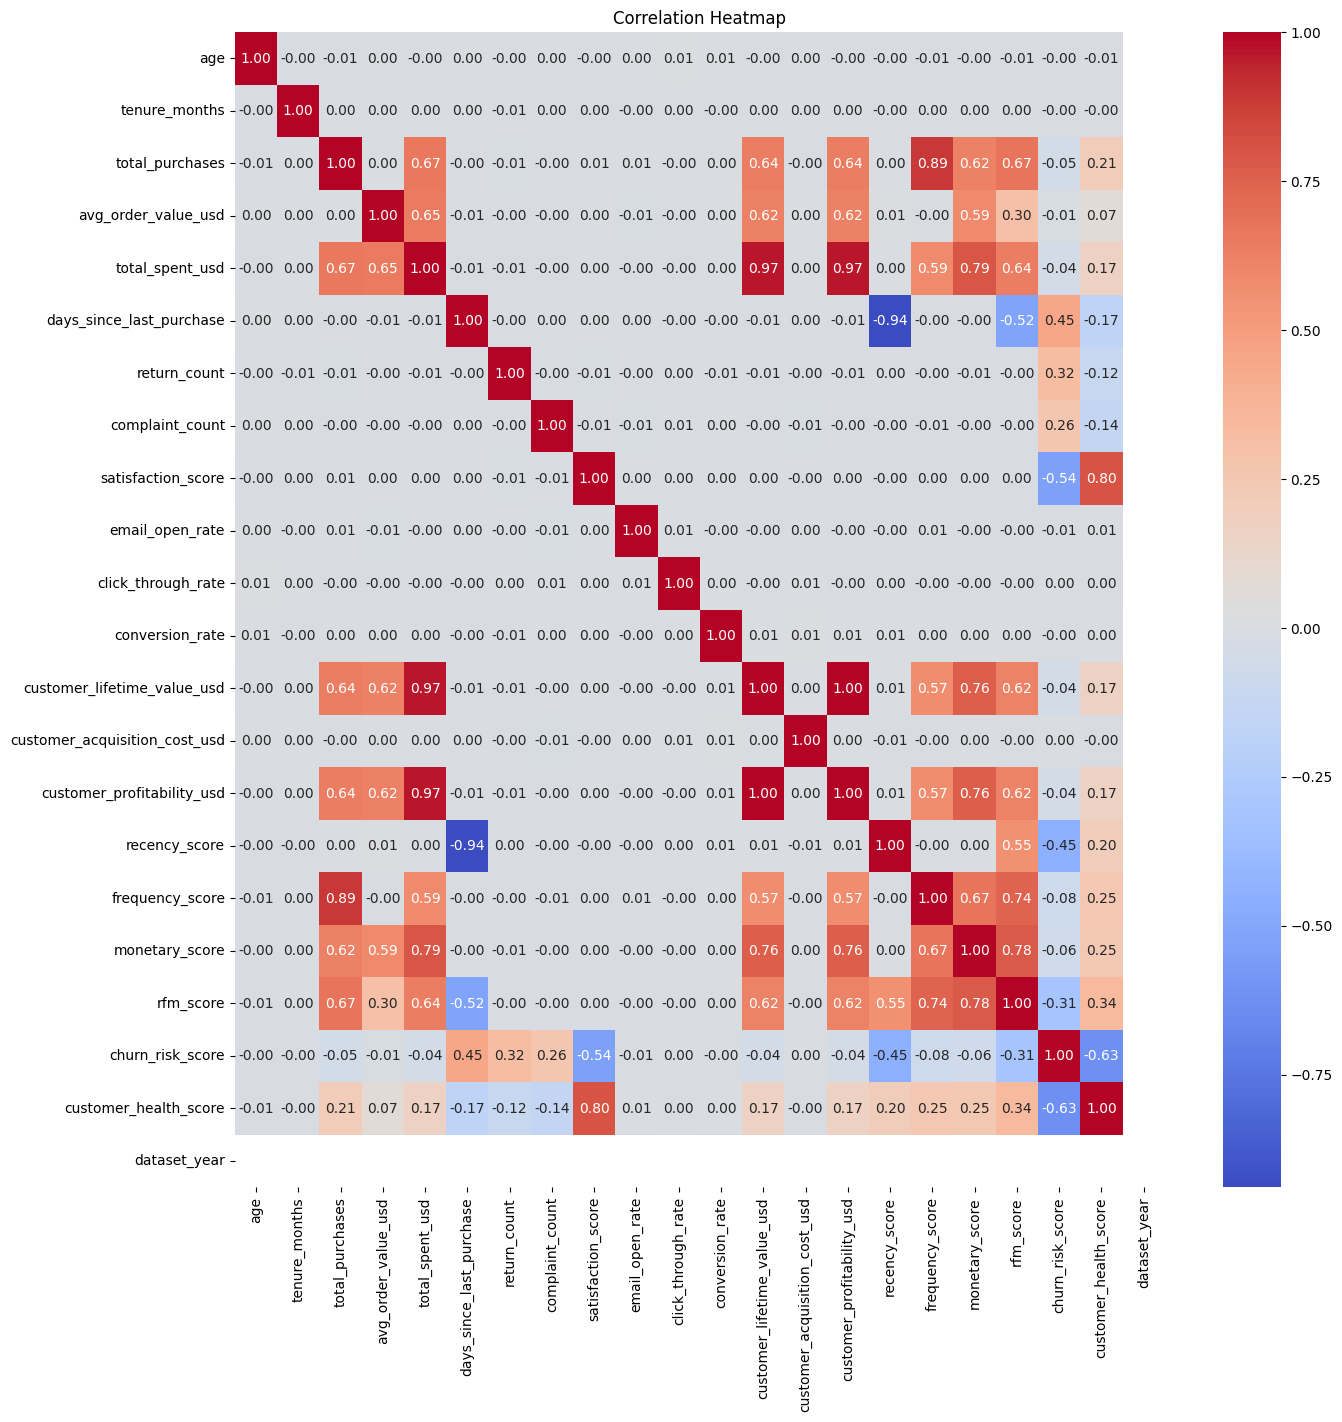

In [11]:
plt.figure(figsize = (15,15))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

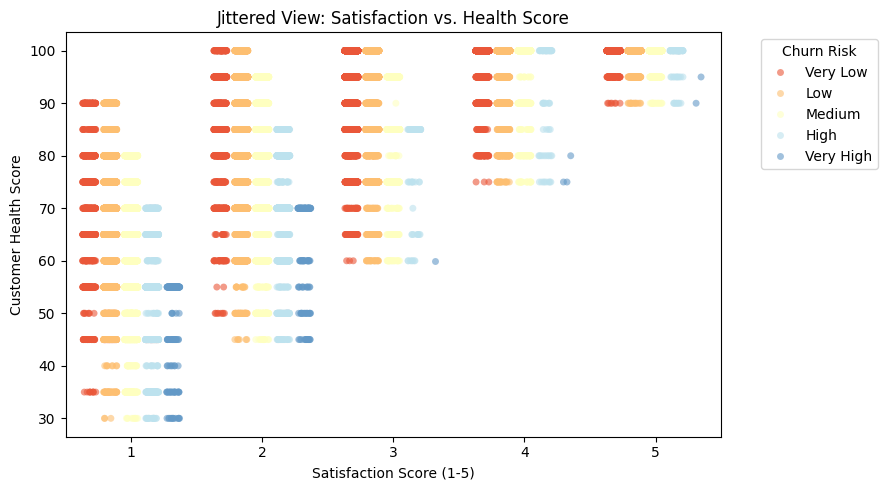

In [12]:
sample_df = df.sample(50000, random_state=42)

plt.figure(figsize = (9, 5))
sns.stripplot(
    data = sample_df, 
    x = 'satisfaction_score', 
    y = 'customer_health_score', 
    hue = 'churn_risk_category',
    palette = 'RdYlBu',
    jitter = 0.25, 
    alpha = 0.6, 
    dodge = True
)

plt.title('Jittered View: Satisfaction vs. Health Score')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Customer Health Score')
plt.legend(title = 'Churn Risk', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

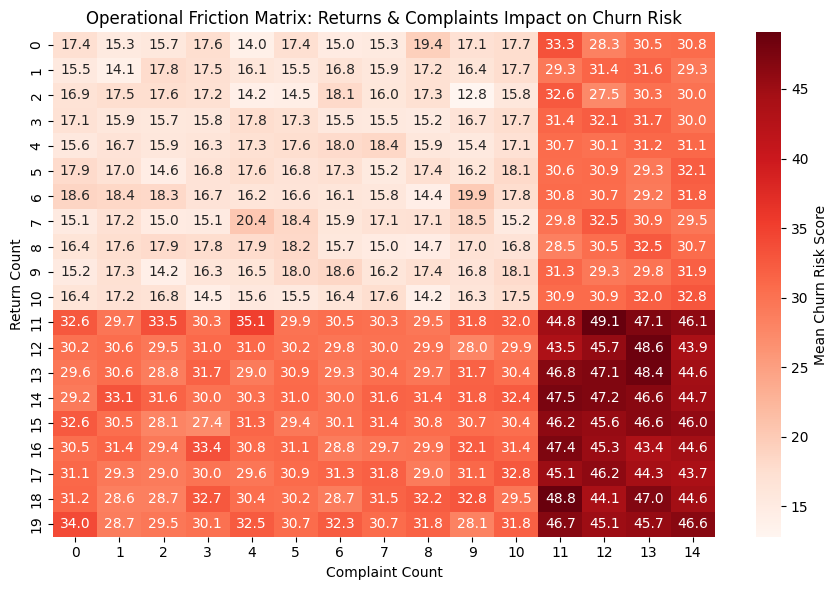

In [13]:
pivot_churn = df.pivot_table(
    index = 'return_count', 
    columns = 'complaint_count', 
    values = 'churn_risk_score', 
    aggfunc = 'mean'
)

plt.figure(figsize = (9, 6))
sns.heatmap(pivot_churn, annot = True, fmt = ".1f", cmap = "Reds", cbar_kws = {'label': 'Mean Churn Risk Score'})
plt.title("Operational Friction Matrix: Returns & Complaints Impact on Churn Risk")
plt.xlabel("Complaint Count")
plt.ylabel("Return Count")
plt.tight_layout()
plt.show()

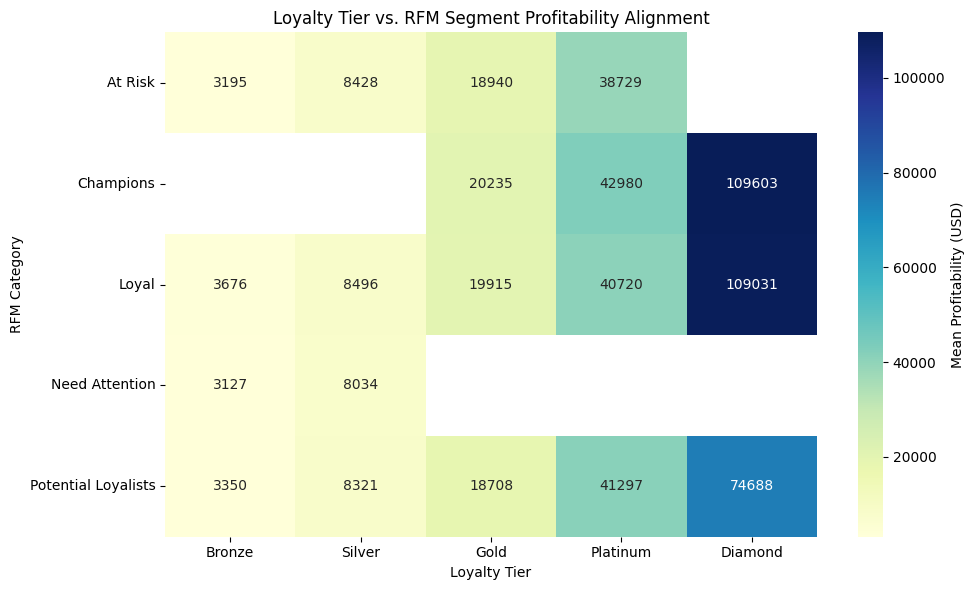

In [14]:
rfm_loyalty = df.pivot_table(
    index = 'rfm_category', 
    columns = 'loyalty_tier', 
    values = 'customer_profitability_usd', 
    aggfunc = 'mean'
).reindex(columns = loyalty_order)

plt.figure(figsize = (10, 6))
sns.heatmap(rfm_loyalty, annot = True, fmt = ".0f", cmap = "YlGnBu", cbar_kws = {'label': 'Mean Profitability (USD)'})
plt.title("Loyalty Tier vs. RFM Segment Profitability Alignment")
plt.xlabel("Loyalty Tier")
plt.ylabel("RFM Category")
plt.tight_layout()
plt.show()

# Labeling Data

In [15]:
df['is_churned'] = df['activity_status'].isin(['Dormant', 'Inactive']).astype(int)
df["is_churned"].value_counts()

is_churned
0    34649
1    15351
Name: count, dtype: int64

In [16]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

education_map = {'High School': 1, 'Bachelors': 2, 'Masters': 3, 'Professional': 4, 'PhD': 5}
income_map = {'0-25K': 1, '25K-50K': 2, '50K-75K': 3, '75K-100K': 4, '100K-150K': 5, '150K+': 6}
frequency_map = {'Rarely': 1, 'Quarterly': 2, 'Monthly': 3, 'Weekly': 4, 'Daily': 5}
loyalty_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4, 'Diamond': 5}
engagement_map = {'Low': 1, 'Medium': 2, 'High': 3}

df['education_level'] = df['education_level'].map(education_map)
df['income_bracket'] = df['income_bracket'].map(income_map)
df['purchase_frequency'] = df['purchase_frequency'].map(frequency_map) 
df['loyalty_tier'] = df['loyalty_tier'].map(loyalty_map).fillna(0)
df['engagement_level'] = df['engagement_level'].map(engagement_map)

# Feature Selection

In [17]:
nominal_cols = ['customer_segment', 'country', 'employment_type', 'marital_status', 'preferred_category_1', 'shopping_channel', 'device_used', 'payment_method']
features = ['purchase_frequency', 'customer_segment', 'age', 'gender', 'country', 'income_bracket', 'education_level', 'employment_type', 'marital_status', 'tenure_months', 'total_purchases', 'avg_order_value_usd', 'total_spent_usd', 'preferred_category_1', 'shopping_channel', 'device_used', 'payment_method', 'return_count', 'complaint_count', 'satisfaction_score', 'loyalty_tier', 'email_open_rate', 'click_through_rate', 'conversion_rate', 'customer_acquisition_cost_usd', 'engagement_level']

X = df[features]
y = df['is_churned']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)
X.head()

,purchase_frequency,age,gender,income_bracket,education_level,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,return_count,...,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Mobile,device_used_Multiple,device_used_Tablet,payment_method_Cash on Delivery,payment_method_Credit Card,payment_method_Debit Card,payment_method_Digital Wallet
0,2,70,0,6,4,77,28,912.60,25552.80,15,...,False,False,False,False,False,True,False,False,True,False
1,1,53,1,2,1,80,75,300.86,22564.50,1,...,True,False,False,False,False,False,False,False,False,False
2,2,82,0,4,2,86,163,663.91,108217.33,1,...,False,False,False,False,False,True,False,False,False,False
3,4,18,0,6,3,26,192,613.60,117811.20,11,...,False,False,True,True,False,False,False,True,False,False
4,4,64,0,6,5,90,31,651.65,20201.15,7,...,False,False,True,False,False,False,False,True,False,False


# Train/Test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Comparison

In [19]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Random Forest:
accuracy: 0.901800
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      6930
           1       0.81      0.89      0.85      3070

    accuracy                           0.90     10000
   macro avg       0.88      0.90      0.89     10000
weighted avg       0.91      0.90      0.90     10000



Text(0.5, 1.0, 'Random Forest Confusion Matrix')

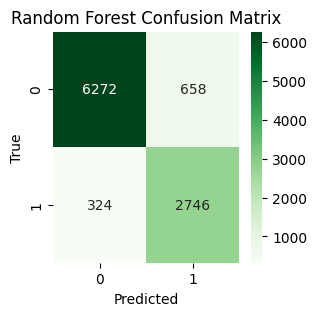

In [20]:
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest:")
print(f"accuracy: {accuracy:.6f}")
print(class_report)

plt.figure(figsize = (3,3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Greens')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")

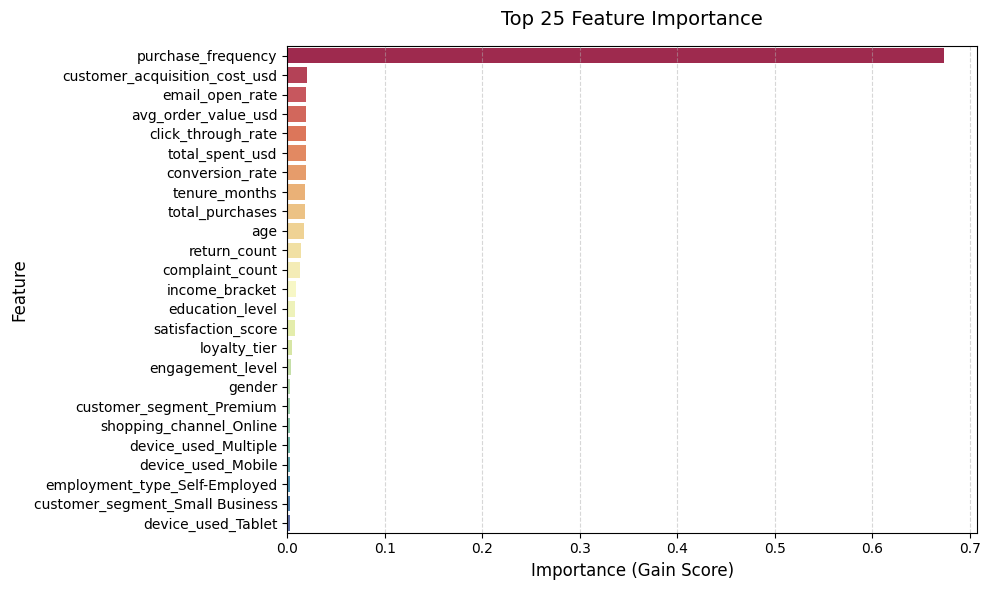

Ranked Features:
                                    Feature  Importance
                         purchase_frequency    0.673883
              customer_acquisition_cost_usd    0.020503
                            email_open_rate    0.019744
                        avg_order_value_usd    0.019717
                         click_through_rate    0.019509
                            total_spent_usd    0.019083
                            conversion_rate    0.018823
                              tenure_months    0.018260
                            total_purchases    0.018013
                                        age    0.017160
                               return_count    0.013933
                            complaint_count    0.013199
                             income_bracket    0.008664
                            education_level    0.007877
                         satisfaction_score    0.007578
                               loyalty_tier    0.005266
                           enga

In [21]:
importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_n_df = 25
top_features_df = importance_df.head(top_n_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features_df,
    x='Importance',
    y='Feature',
    hue='Feature',    
    palette='Spectral',
    legend=False
)

plt.title('Top 25 Feature Importance', fontsize=14, pad=15)
plt.xlabel('Importance (Gain Score)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Ranked Features:")
print(importance_df.to_string(index=False))

Logistic Regression:
accuracy: 0.902800
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      6930
           1       0.82      0.88      0.85      3070

    accuracy                           0.90     10000
   macro avg       0.88      0.90      0.89     10000
weighted avg       0.91      0.90      0.90     10000



Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

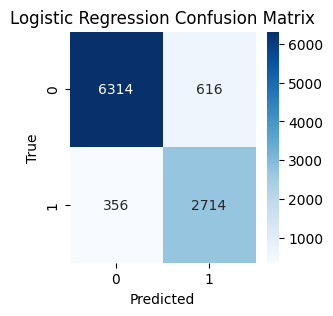

In [22]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)

conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

print("Logistic Regression:")
print(f"accuracy: {accuracy_log_reg:.6f}")
print(class_report_log_reg)

plt.figure(figsize=(3,3))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")

KNN:
accuracy: 0.728600
              precision    recall  f1-score   support

           0       0.76      0.90      0.82      6930
           1       0.60      0.35      0.44      3070

    accuracy                           0.73     10000
   macro avg       0.68      0.62      0.63     10000
weighted avg       0.71      0.73      0.70     10000



Text(0.5, 1.0, 'KNN Confusion Matrix')

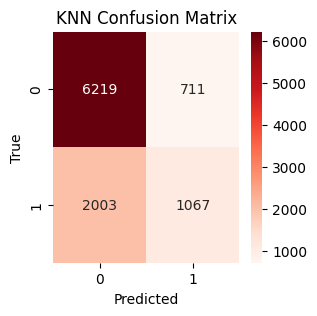

In [23]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model. predict(X_test)

conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN:")
print(f"accuracy: {accuracy_knn:.6f}")
print(class_report_knn)

plt.figure(figsize=(3,3))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KNN Confusion Matrix")

SVM:
accuracy: 0.903400
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      6930
           1       0.82      0.89      0.85      3070

    accuracy                           0.90     10000
   macro avg       0.88      0.90      0.89     10000
weighted avg       0.91      0.90      0.90     10000



Text(0.5, 1.0, 'SVM Confusion Matrix')

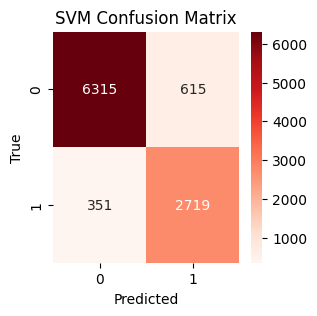

In [24]:
svm_model = LinearSVC(dual=False, random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM:")
print(f"accuracy: {accuracy_svm:.6f}")
print(class_report_svm)

plt.figure(figsize=(3,3))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix")

GBM:
accuracy: 0.902100
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      6930
           1       0.80      0.91      0.85      3070

    accuracy                           0.90     10000
   macro avg       0.88      0.90      0.89     10000
weighted avg       0.91      0.90      0.90     10000



Text(0.5, 1.0, 'GBM Confusion Matrix')

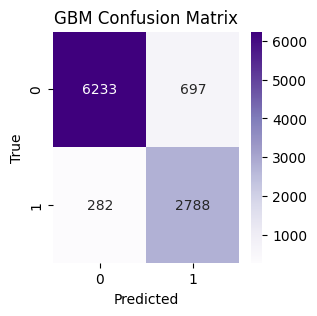

In [25]:
gbm_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm_model.fit(X_train, y_train)

y_pred_gbm = gbm_model.predict(X_test)

conf_matrix_gbm = confusion_matrix(y_test, y_pred_gbm)
class_report_gbm = classification_report(y_test, y_pred_gbm)
accuracy_gbm = accuracy_score(y_test, y_pred_gbm)

print("GBM:")
print(f"accuracy: {accuracy_gbm:.6f}")
print(class_report_gbm)

plt.figure(figsize=(3,3))
sns.heatmap(conf_matrix_gbm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GBM Confusion Matrix")

Gaussian Naive Bayes:
accuracy: 0.902500
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      6930
           1       0.79      0.93      0.85      3070

    accuracy                           0.90     10000
   macro avg       0.88      0.91      0.89     10000
weighted avg       0.91      0.90      0.90     10000



Text(0.5, 1.0, 'Gaussian Naive Bayes Confusion Matrix')

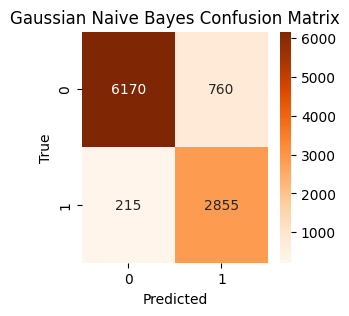

In [26]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb= nb_model.predict(X_test)

conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
class_report_nb = classification_report(y_test, y_pred_nb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Gaussian Naive Bayes:")
print(f"accuracy: {accuracy_nb:.6f}")
print(class_report_nb)

plt.figure(figsize=(3,3))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Gaussian Naive Bayes Confusion Matrix")

In [27]:
financial_df = pd.DataFrame(X_test, columns=X.columns, index=y_test.index)
financial_df['actual_churn'] = y_test
financial_df['predicted_churn'] = y_pred_nb

financial_df['customer_lifetime_value_usd'] = df.loc[y_test.index, 'customer_lifetime_value_usd']
tp_mask = (financial_df['actual_churn'] == 1) & (financial_df['predicted_churn'] == 1)
actual_churners = financial_df[financial_df['actual_churn'] == 1]
recall_score_val = len(financial_df[tp_mask]) / len(actual_churners)
recall_pct = recall_score_val * 100

clv_at_risk_identified = financial_df.loc[tp_mask, 'customer_lifetime_value_usd'].sum()
total_actual_churn_clv = actual_churners['customer_lifetime_value_usd'].sum()

print(f"Model Recall (Churn Class): {recall_pct:.1f}%")
print(f"Total CLV of all actual churners in test set: ${total_actual_churn_clv:,.2f}")
print(f"Retaining the {recall_pct:.1f}% of churn-risk customers identified by the model saves ${clv_at_risk_identified:,.2f} in lost CLV.")

campaign_success_rate = 0.30 
realistic_savings = clv_at_risk_identified * campaign_success_rate
print(f"Assuming a {campaign_success_rate * 100} % campaign retention rate, utilizing this model saves an estimated ${realistic_savings:,.2f}.")

Model Recall (Churn Class): 93.0%
Total CLV of all actual churners in test set: $181,222,484.63
Retaining the 93.0% of churn-risk customers identified by the model saves $165,925,856.02 in lost CLV.
Assuming a 30.0 % campaign retention rate, utilizing this model saves an estimated $49,777,756.81.


# Feature Engeneering

In [28]:
df['purchase_velocity'] = df['total_purchases'] / (df['tenure_months'] + 1)
df['monthly_spend'] = df['total_spent_usd'] / (df['tenure_months'] + 1)
df['return_rate'] = df['return_count'] / (df['total_purchases'] + 1)
df['complaint_rate'] = df['complaint_count'] / (df['total_purchases'] + 1)
df['ctor'] = df['click_through_rate'] / (df['email_open_rate'] + 1e-5)
df['clv_cac_ratio'] = df['customer_lifetime_value_usd'] / (df['customer_acquisition_cost_usd'] + 1)
df['num_preferred_categories'] = df[['preferred_category_1', 'preferred_category_2', 'preferred_category_3']].notna().sum(axis=1)
df['high_risk_dissatisfaction'] = ((df['satisfaction_score'] <= 2) & (df['complaint_count'] > 0)).astype(int)

leakage_and_id_cols = ['customer_id', 'activity_status', 'days_since_last_purchase',
                       'recency_score', 'rfm_score', 'rfm_category', 'churn_risk_score',
                       'churn_risk_category', 'customer_health_score', 'health_status', 'is_churned']

X = df.drop(columns=[col for col in leakage_and_id_cols if col in df.columns]).copy()
y = df['is_churned']

In [29]:
cat_cols = X.select_dtypes(include=['object', 'string']).columns
X[cat_cols] = X[cat_cols].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

xgb_model = XGBClassifier(n_estimators = 300, learning_rate = 0.03, max_depth = 6, subsample = 0.8, colsample_bytree = 0.8,
                          enable_categorical = True,  random_state = 42, eval_metric = 'logloss', n_jobs = -1)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


XGBoost:
accuracy: 0.904000
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6930
           1       0.83      0.86      0.85      3070

    accuracy                           0.90     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.90      0.90      0.90     10000



Text(0.5, 1.0, 'XGBoost Confusion Matrix')

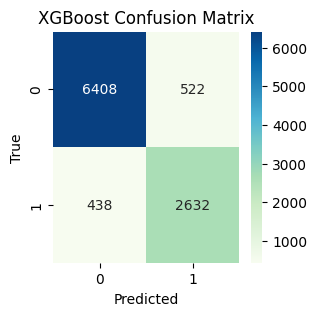

In [30]:
y_pred = xgb_model.predict(X_test)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

conf_matrix_xgb = confusion_matrix(y_test, y_pred)
class_report_xgb = classification_report(y_test, y_pred)
accuracy_xgb = accuracy_score(y_test, y_pred)

print("XGBoost:")
print(f"accuracy: {accuracy_xgb:.6f}")
print(class_report_xgb)

plt.figure(figsize=(3,3))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='GnBu')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost Confusion Matrix")

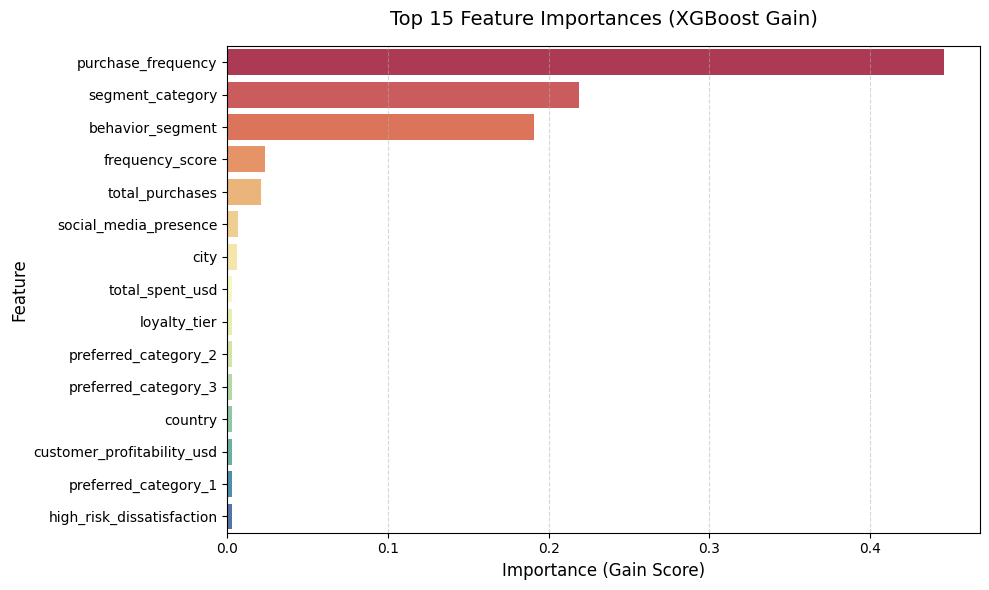

Top 15 Most Important Features:
                   Feature  Importance
        purchase_frequency    0.446042
          segment_category    0.219088
          behavior_segment    0.191017
           frequency_score    0.023590
           total_purchases    0.020832
     social_media_presence    0.006440
                      city    0.006279
           total_spent_usd    0.002792
              loyalty_tier    0.002762
      preferred_category_2    0.002736
      preferred_category_3    0.002678
                   country    0.002671
customer_profitability_usd    0.002613
      preferred_category_1    0.002586
 high_risk_dissatisfaction    0.002576


In [31]:
importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_n = 15
top_features = importance_xgb.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',    
    hue='Feature',    
    palette='Spectral',
    legend=False
)

plt.title(f'Top {top_n} Feature Importances (XGBoost Gain)', fontsize=14, pad=15)
plt.xlabel('Importance (Gain Score)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 15 Most Important Features:")
print(top_features.to_string(index=False))

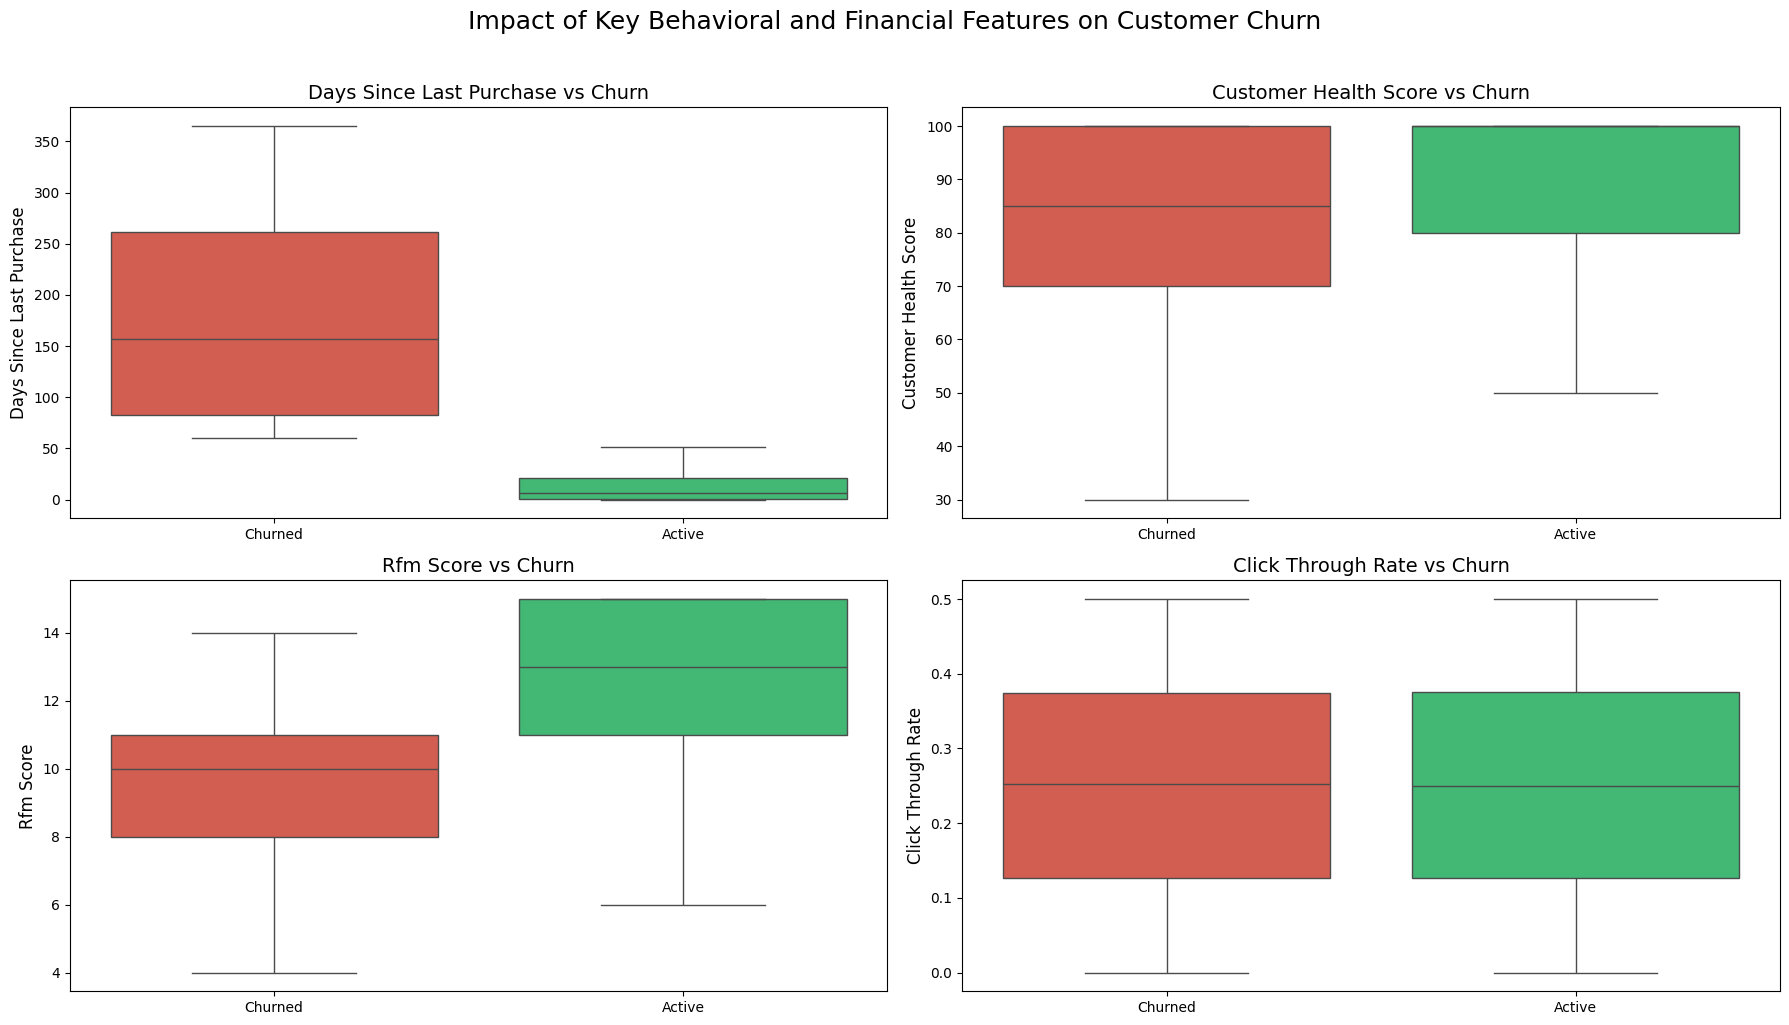

       Churn Insights: Median Values by Feature
Churn Label               Active  Churned  % Difference
days_since_last_purchase   6.000  157.000      2516.670
customer_health_score    100.000   85.000       -15.000
rfm_score                 13.000   10.000       -23.080
click_through_rate         0.250    0.252         0.800


In [32]:
df['Churn Label'] = df['is_churned'].map({1: 'Churned', 0: 'Active'})

features_to_analyze = [
    'days_since_last_purchase',
    'customer_health_score',   
    'rfm_score',               
    'click_through_rate'   
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Impact of Key Behavioral and Financial Features on Customer Churn', fontsize=18, y=1.02)
axes = axes.flatten()

palette = {'Active': '#2ecc71', 'Churned': '#e74c3c'}

for i, feature in enumerate(features_to_analyze):
    sns.boxplot(
        data=df, 
        x='Churn Label', 
        y=feature, 
        hue='Churn Label',
        legend=False,   
        ax=axes[i], 
        palette=palette,
        showfliers=False 
    )
    
    axes[i].set_title(f'{feature.replace("_", " ").title()} vs Churn', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature.replace("_", " ").title(), fontsize=12)

plt.tight_layout()
plt.show()

print("       Churn Insights: Median Values by Feature")
insights_df = df.groupby('Churn Label')[features_to_analyze].median().T

if 'Active' in insights_df.columns and 'Churned' in insights_df.columns:
    insights_df['% Difference'] = ((insights_df['Churned'] - insights_df['Active']) / insights_df['Active'] * 100).round(2)

print(insights_df.to_string(float_format="{:.3f}".format))

In [33]:
financial_df = X_test.copy()
financial_df['actual_churn'] = y_test
financial_df['predicted_churn'] = y_pred

tp_mask = (financial_df['actual_churn'] == 1) & (financial_df['predicted_churn'] == 1)
actual_churners = financial_df[financial_df['actual_churn'] == 1]
recall_score = len(financial_df[tp_mask]) / len(actual_churners)
recall_pct = recall_score * 100

clv_at_risk_identified = financial_df.loc[tp_mask, 'customer_lifetime_value_usd'].sum()
total_actual_churn_clv = actual_churners['customer_lifetime_value_usd'].sum()

print(f"Model Recall (Churn Class): {recall_pct:.1f}%")
print(f"Total CLV of all actual churners in test set: ${total_actual_churn_clv:,.2f}")
print(f"Retaining the {recall_pct:.1f}% of churn-risk customers identified by the model saves ${clv_at_risk_identified:,.2f} in lost CLV.")

campaign_success_rate = 0.30 
realistic_savings = clv_at_risk_identified * campaign_success_rate
print(f"Assuming a 30% campaign retention rate, utilizing this model saves an estimated ${realistic_savings:,.2f}.")

Model Recall (Churn Class): 85.7%
Total CLV of all actual churners in test set: $181,222,484.63
Retaining the 85.7% of churn-risk customers identified by the model saves $155,700,251.86 in lost CLV.
Assuming a 30% campaign retention rate, utilizing this model saves an estimated $46,710,075.56.
